<a href="https://colab.research.google.com/github/AROO-6/Codesoft-Task/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn xgboost shap imbalanced-learn pandas matplotlib seaborn --quiet
print("All packages installed!")

All packages installed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from xgboost                 import XGBClassifier

# Preprocessing
from sklearn.preprocessing   import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline        import Pipeline

# Imbalance
from imblearn.over_sampling  import SMOTE

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)

# Explainability
import shap
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
print("All imports done!")

All imports done!


In [ ]:
# Download the Telco Churn dataset directly
!wget -q "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv" -O telco_churn.csv

df = pd.read_csv('telco_churn.csv')
print(f"Dataset loaded: {df.shape[0]:,} customers, {df.shape[1]} columns")
df.head()

Dataset loaded: 7,043 customers, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Basic overview
print("Column types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
Series([], dtype: int64)

Total missing: 0


Churn distribution:
  Stayed  (No) : 5,174  (73.5%)
  Churned (Yes): 1,869  (26.5%)


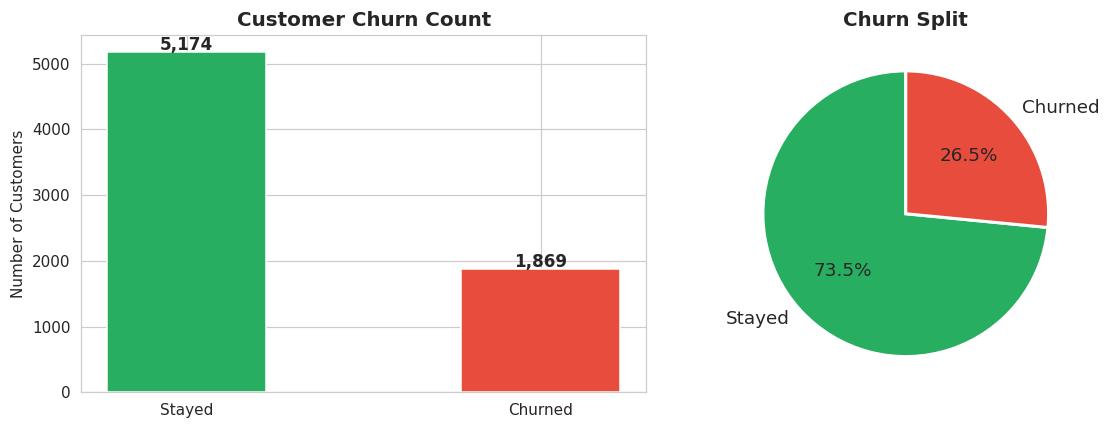

In [ ]:
# Overall churn distribution
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print("Churn distribution:")
print(f"  Stayed  (No) : {churn_counts['No']:,}  ({churn_pct['No']:.1f}%)")
print(f"  Churned (Yes): {churn_counts['Yes']:,}  ({churn_pct['Yes']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar
axes[0].bar(['Stayed', 'Churned'], churn_counts.values,
            color=['#27ae60', '#e74c3c'], edgecolor='white', width=0.45)
axes[0].set_title('Customer Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 40, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Pie
axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'],
            colors=['#27ae60', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Churn Split', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

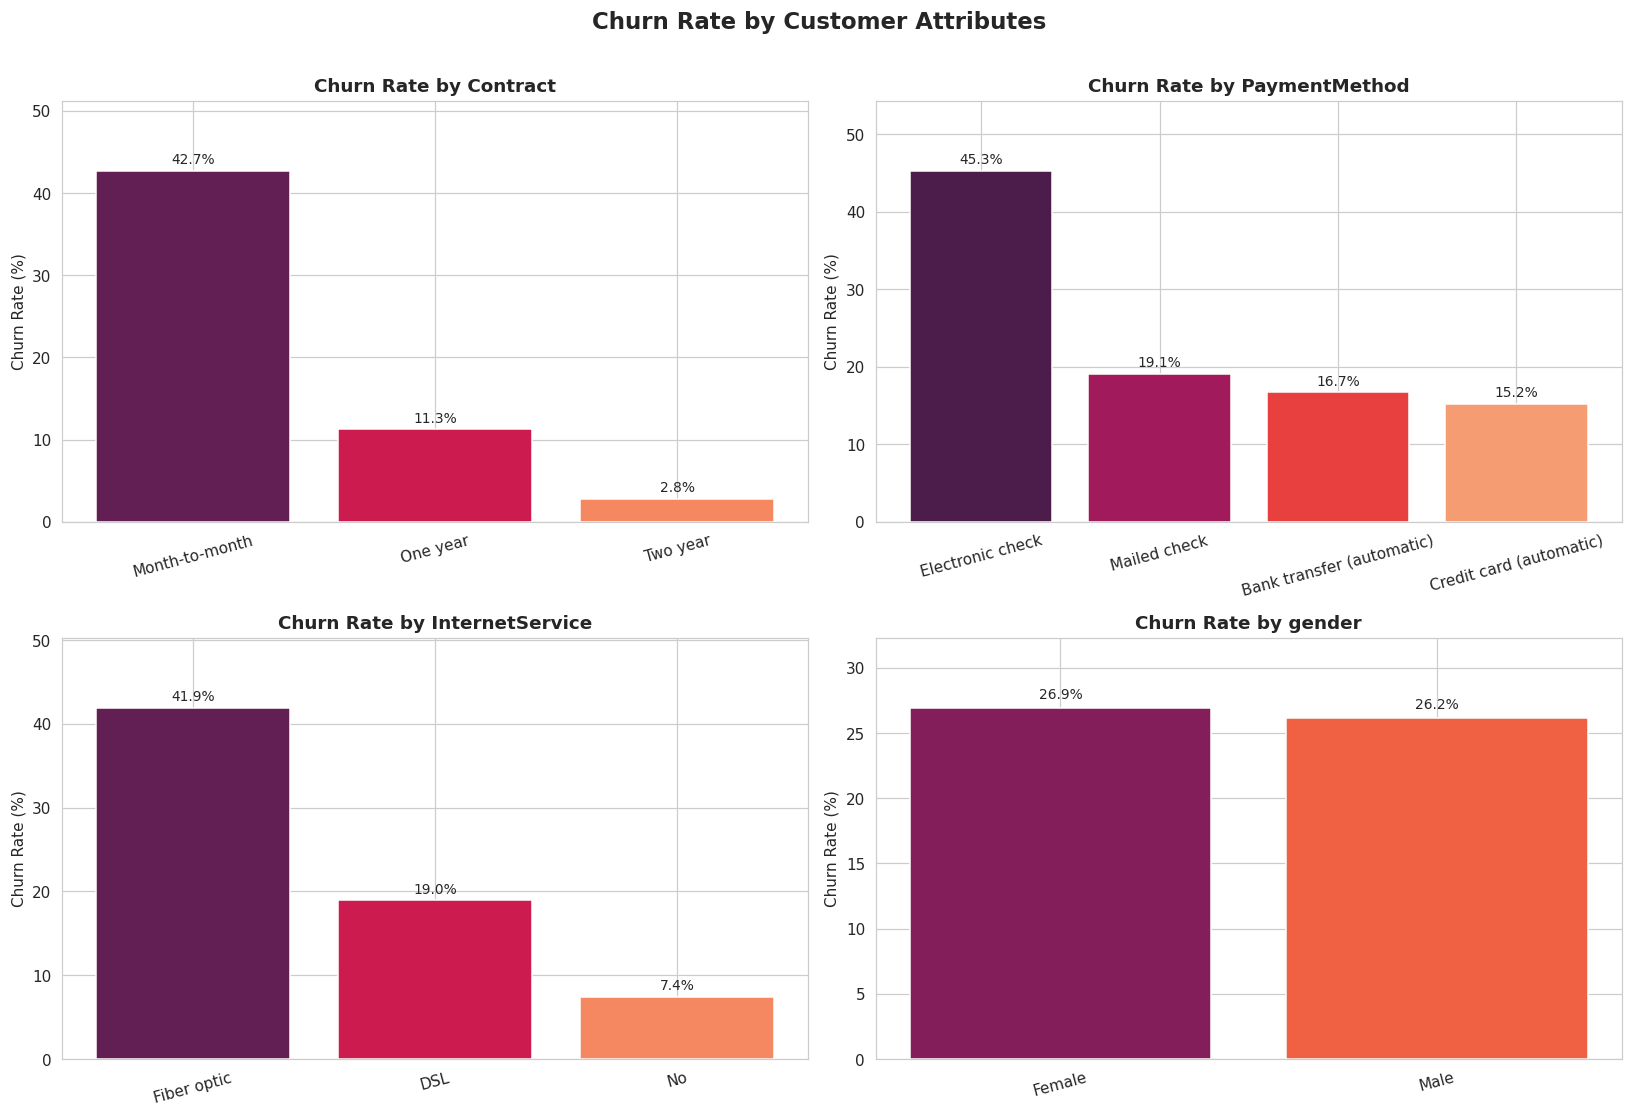

In [ ]:
# Churn by contract type, payment method, and internet service
cat_features = ['Contract', 'PaymentMethod', 'InternetService', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)

    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=sns.color_palette('rocket', len(churn_rate)),
                       edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, churn_rate.max() * 1.2)
    axes[i].tick_params(axis='x', rotation=15)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%',
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('Churn Rate by Customer Attributes', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

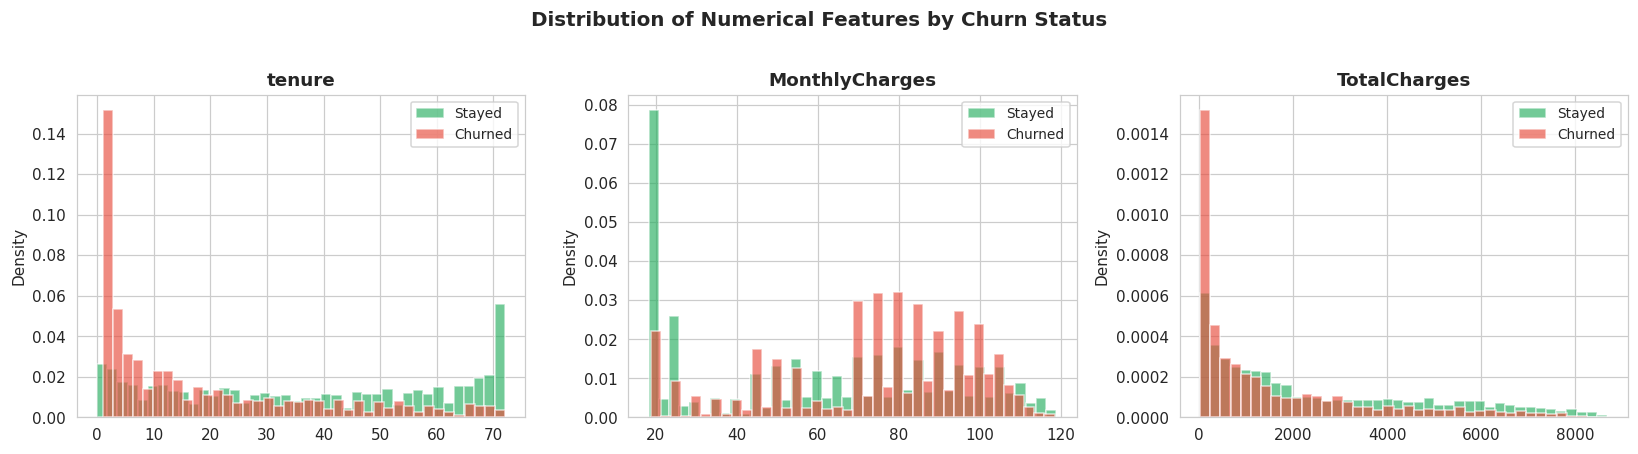

Key observations:
  - Short-tenure customers churn more (new customers are riskier)
  - Higher monthly charges correlate with higher churn
  - Lower total charges = less time with the company = more churn


In [ ]:
# Numerical features: tenure, MonthlyCharges, TotalCharges
# Convert TotalCharges to numeric first (it comes in as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_features):
    stayed  = df[df['Churn'] == 'No'][col].dropna()
    churned = df[df['Churn'] == 'Yes'][col].dropna()

    axes[i].hist(stayed,  bins=40, alpha=0.65, color='#27ae60', label='Stayed',  density=True)
    axes[i].hist(churned, bins=40, alpha=0.65, color='#e74c3c', label='Churned', density=True)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Numerical Features by Churn Status',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  - Short-tenure customers churn more (new customers are riskier)")
print("  - Higher monthly charges correlate with higher churn")
print("  - Lower total charges = less time with the company = more churn")

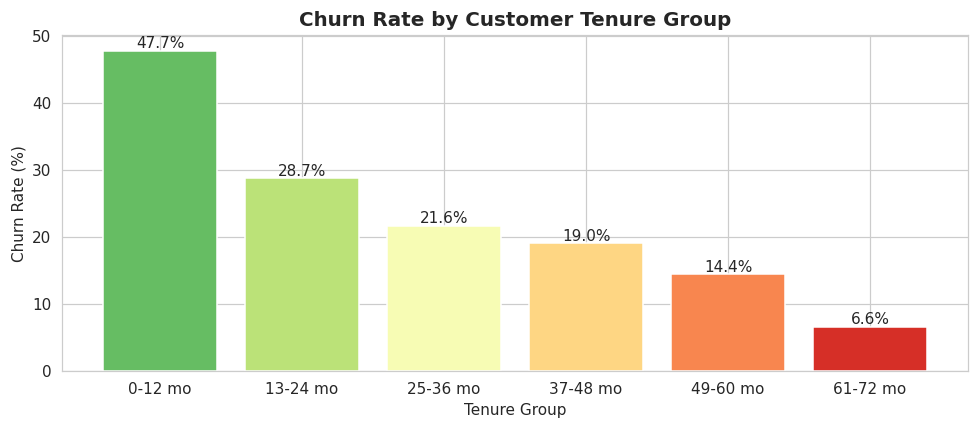

In [ ]:
# Tenure bins — churn rate across customer lifetime stages
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12 mo', '13-24 mo', '25-36 mo', '37-48 mo', '49-60 mo', '61-72 mo']
)

churn_by_tenure = (
    df.groupby('tenure_group')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

plt.figure(figsize=(9, 4))
bars = plt.bar(churn_by_tenure.index.astype(str), churn_by_tenure.values,
               color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(churn_by_tenure))),
               edgecolor='white')
plt.title('Churn Rate by Customer Tenure Group', fontsize=13, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
def prepare_data(dataframe):
    df = dataframe.copy()

    # Drop customer ID — not useful for prediction
    if 'customerID' in df.columns:
        df.drop(columns=['customerID'], inplace=True)

    # Fix TotalCharges
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

    # Drop the tenure_group we created earlier (it was just for EDA)
    if 'tenure_group' in df.columns:
        df.drop(columns=['tenure_group'], inplace=True)

    # --- Feature Engineering ---

    # Average monthly spend relative to how long they've been a customer
    df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

    # How many services has this customer subscribed to?
    service_cols = [
        'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    df['num_services'] = df[service_cols].apply(
        lambda row: sum(1 for v in row if v not in ['No', 'No phone service', 'No internet service']),
        axis=1
    )

    # Is the customer on a month-to-month contract? (highest risk)
    df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

    # Is the customer using paperless billing?
    df['is_paperless'] = (df['PaperlessBilling'] == 'Yes').astype(int)

    # Senior citizen flag
    # (already numeric 0/1 in this dataset)

    # --- Encode target ---
    df['Churn'] = (df['Churn'] == 'Yes').astype(int)

    # --- Encode binary categoricals ---
    binary_yes_no = [
        'gender', 'Partner', 'Dependents', 'PhoneService',
        'PaperlessBilling'
    ]
    for col in binary_yes_no:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

    # --- One-hot encode multi-class categoricals ---
    multi_cat = [
        'MultipleLines', 'InternetService', 'OnlineSecurity',
        'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
    ]
    multi_cat = [c for c in multi_cat if c in df.columns]
    df = pd.get_dummies(df, columns=multi_cat, drop_first=True)

    return df


print("Preparing data...")
df_clean = prepare_data(df)
print(f"Clean dataset shape: {df_clean.shape}")
print(f"Churn rate: {df_clean['Churn'].mean()*100:.1f}%")
df_clean.head(3)

Preparing data...
Clean dataset shape: (7043, 35)
Churn rate: 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


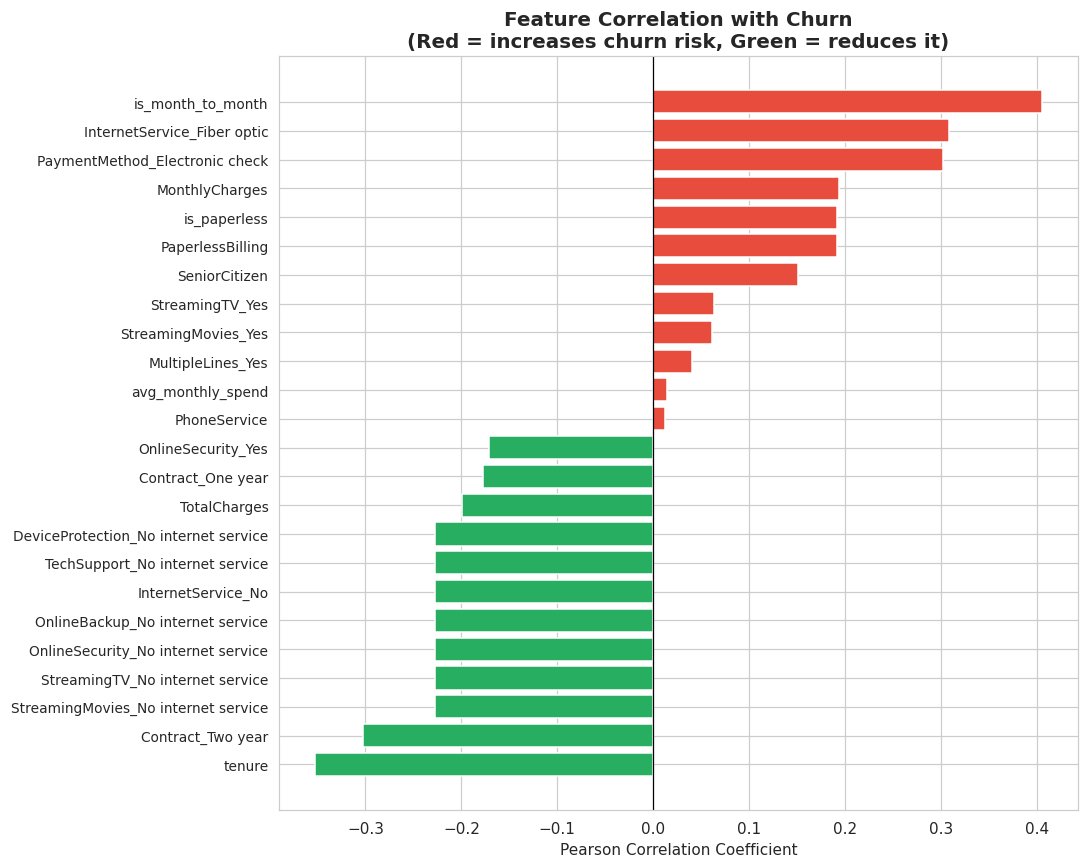

In [ ]:
# Correlation with churn — which features matter most?
corr_with_churn = (
    df_clean.corr()['Churn']
    .drop('Churn')
    .sort_values()
)

# Take top 15 positive and top 15 negative
top_corr = pd.concat([corr_with_churn.head(12), corr_with_churn.tail(12)])

colors = ['#e74c3c' if v > 0 else '#27ae60' for v in top_corr.values]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor='white')
plt.yticks(range(len(top_corr)), top_corr.index, fontsize=9)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Churn\n(Red = increases churn risk, Green = reduces it)',
          fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

In [ ]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# Stratified split keeps the churn ratio consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Churn in train   : {y_train.mean()*100:.1f}%")
print(f"Churn in test    : {y_test.mean()*100:.1f}%")

Training samples : 5,634
Test samples     : 1,409
Churn in train   : 26.5%
Churn in test    : 26.5%


In [ ]:
# SMOTE balances the classes in the training set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Stayed: {sum(y_train==0):,}  |  Churned: {sum(y_train==1):,}")
print(f"After  SMOTE — Stayed: {sum(y_train_bal==0):,}  |  Churned: {sum(y_train_bal==1):,}")

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

print("\nFeatures scaled.")

Before SMOTE — Stayed: 4,139  |  Churned: 1,495
After  SMOTE — Stayed: 4,139  |  Churned: 4,139

Features scaled.


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        min_samples_split=10, n_jobs=-1, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.08,
        max_depth=5, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ', flush=True)

    # LR uses scaled data; tree models use raw balanced data
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train_bal)
        preds = model.predict(X_test_sc)
        proba = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train_bal, y_train_bal)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    auc  = roc_auc_score(y_test, proba)
    ap   = average_precision_score(y_test, proba)

    results[name] = {
        'model': model, 'preds': preds, 'proba': proba,
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'roc_auc': auc, 'avg_precision': ap
    }

    print(f"Acc: {acc:.3f}  |  F1: {f1:.3f}  |  ROC-AUC: {auc:.3f}")

print("\nAll models trained!")

Training Logistic Regression... Acc: 0.794  |  F1: 0.613  |  ROC-AUC: 0.839
Training Random Forest... Acc: 0.767  |  F1: 0.610  |  ROC-AUC: 0.835
Training Gradient Boosting... Acc: 0.770  |  F1: 0.577  |  ROC-AUC: 0.824
Training XGBoost... Acc: 0.771  |  F1: 0.579  |  ROC-AUC: 0.825

All models trained!


In [ ]:
# Comparison table
summary = pd.DataFrame({
    'Model':         list(results.keys()),
    'Accuracy':      [results[m]['accuracy']      for m in results],
    'Precision':     [results[m]['precision']     for m in results],
    'Recall':        [results[m]['recall']        for m in results],
    'F1 Score':      [results[m]['f1']            for m in results],
    'ROC-AUC':       [results[m]['roc_auc']       for m in results],
    'Avg Precision': [results[m]['avg_precision'] for m in results],
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

summary_display = summary.copy()
for col in summary_display.columns[1:]:
    summary_display[col] = summary_display[col].apply(lambda x: f'{x:.4f}')

print("Model Comparison Results:")
print(summary_display.to_string(index=False))

Model Comparison Results:
              Model Accuracy Precision Recall F1 Score ROC-AUC Avg Precision
Logistic Regression   0.7942    0.6117 0.6150   0.6133  0.8393        0.6566
      Random Forest   0.7672    0.5494 0.6845   0.6095  0.8350        0.6315
            XGBoost   0.7715    0.5667 0.5909   0.5785  0.8253        0.6338
  Gradient Boosting   0.7700    0.5638 0.5909   0.5770  0.8237        0.6193


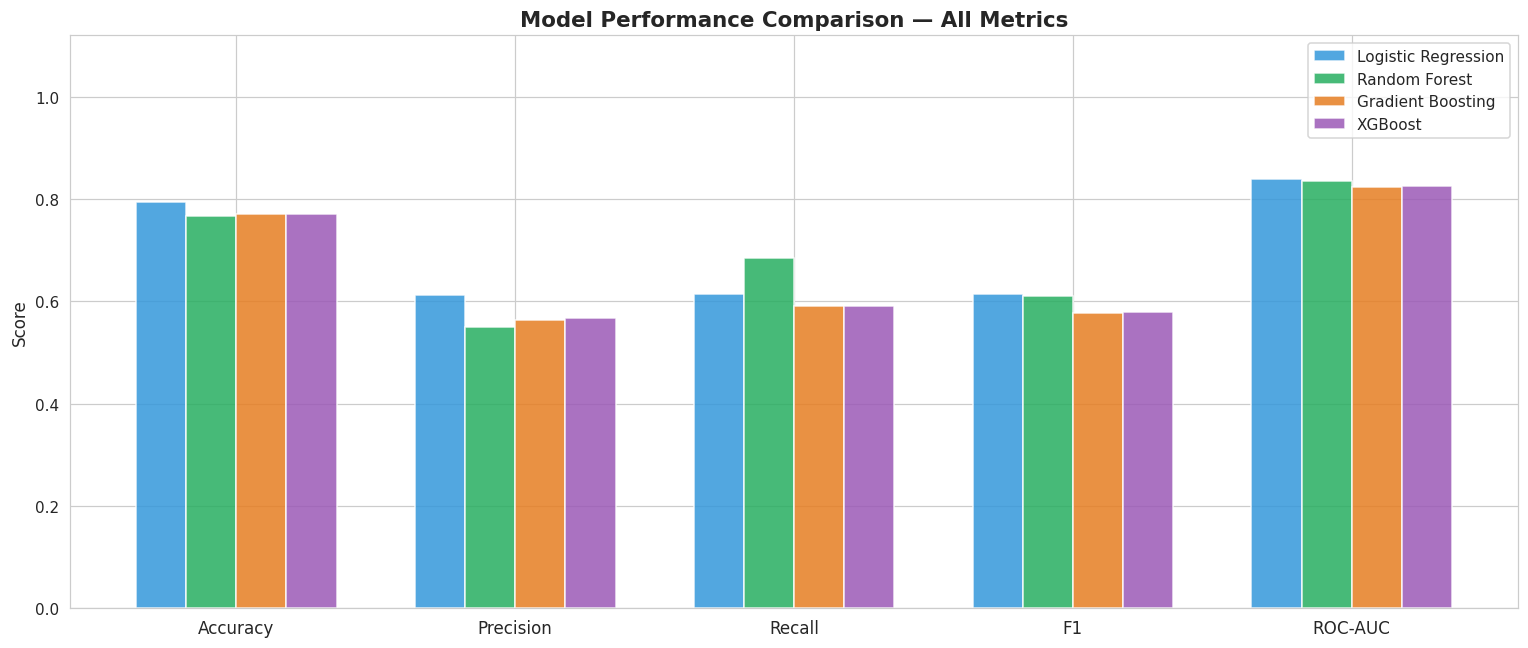

In [ ]:
# Radar / grouped bar chart — all metrics side by side
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels   = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
model_names     = list(results.keys())
palette         = ['#3498db', '#27ae60', '#e67e22', '#9b59b6']

x = np.arange(len(metrics_to_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, color) in enumerate(zip(model_names, palette)):
    vals = [results[name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

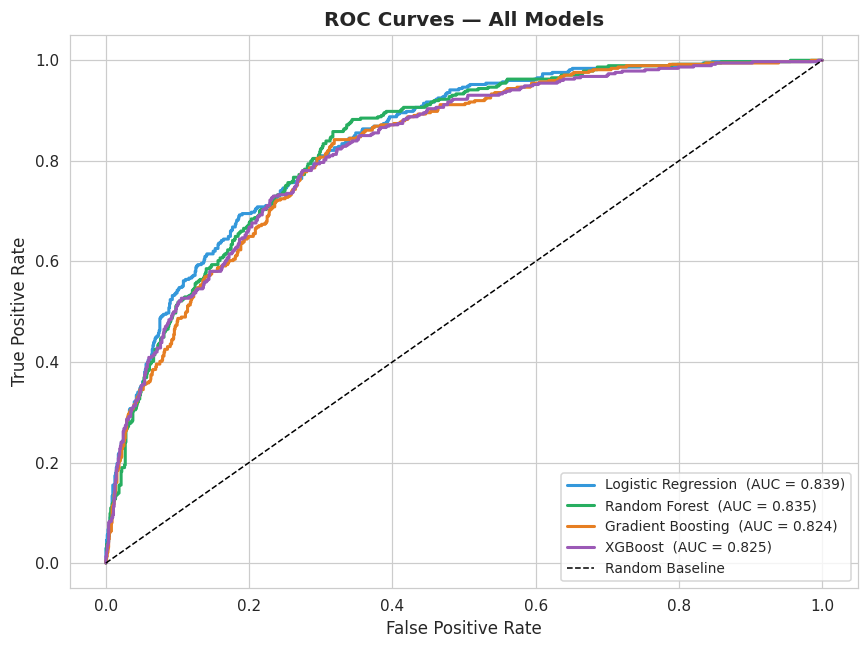

In [ ]:
# ROC curves
plt.figure(figsize=(8, 6))

for name, color in zip(model_names, palette):
    fpr, tpr, _ = roc_curve(y_test, results[name]['proba'])
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f"{name}  (AUC = {results[name]['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

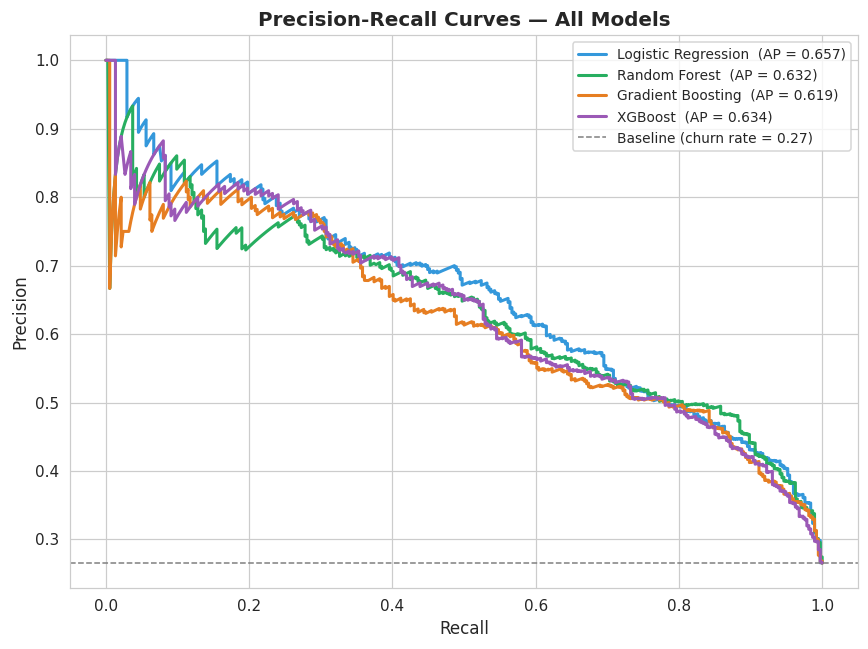

In [ ]:
# Precision-Recall curves
plt.figure(figsize=(8, 6))

for name, color in zip(model_names, palette):
    prec_c, rec_c, _ = precision_recall_curve(y_test, results[name]['proba'])
    plt.plot(rec_c, prec_c, lw=2, color=color,
             label=f"{name}  (AP = {results[name]['avg_precision']:.3f})")

baseline = y_test.mean()
plt.axhline(baseline, color='gray', linestyle='--', lw=1,
            label=f'Baseline (churn rate = {baseline:.2f})')
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
best_name = max(results, key=lambda n: results[n]['roc_auc'])
best      = results[best_name]

print(f"Best model: {best_name}")
print(f"ROC-AUC   : {best['roc_auc']:.4f}")
print(f"F1 Score  : {best['f1']:.4f}")
print()
print(classification_report(y_test, best['preds'],
                             target_names=['Stayed', 'Churned']))

Best model: Logistic Regression
ROC-AUC   : 0.8393
F1 Score  : 0.6133

              precision    recall  f1-score   support

      Stayed       0.86      0.86      0.86      1035
     Churned       0.61      0.61      0.61       374

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.79      0.79      0.79      1409



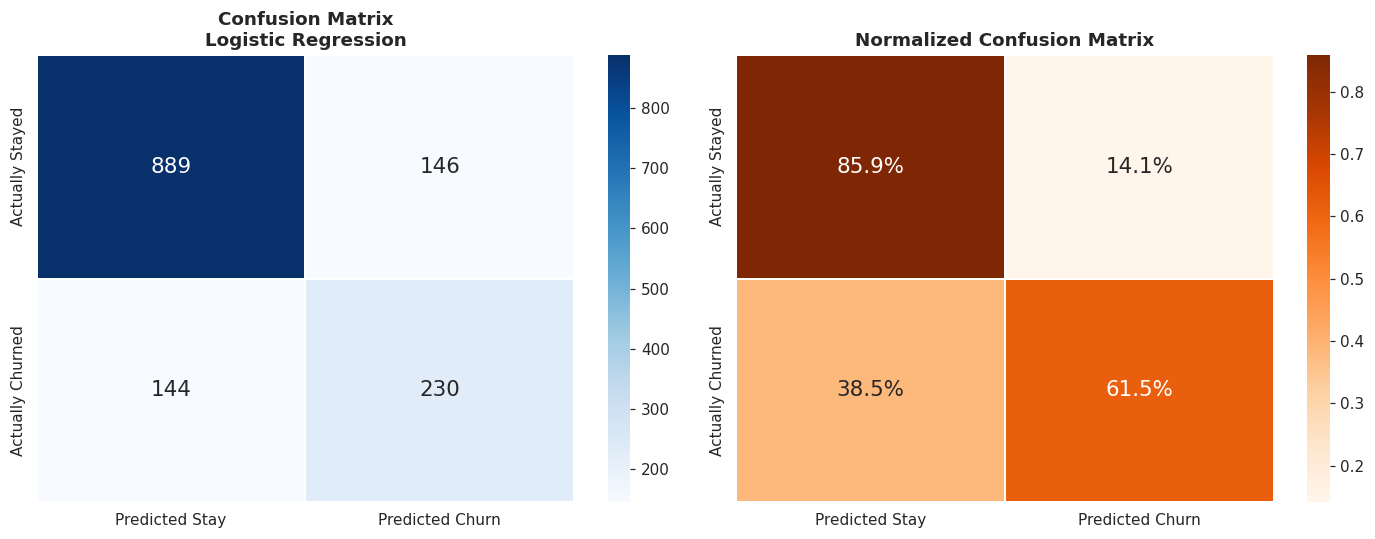

Correctly identified churners : 230  out of 374  (61.5% recall)
False alarms (good customers flagged): 146


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, best['preds'])
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actually Stayed', 'Actually Churned'],
            linewidths=1, annot_kws={'size': 14}, ax=axes[0])
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontsize=12, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Oranges',
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actually Stayed', 'Actually Churned'],
            linewidths=1, annot_kws={'size': 14}, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Correctly identified churners : {tp:,}  out of {tp+fn:,}  ({tp/(tp+fn)*100:.1f}% recall)")
print(f"False alarms (good customers flagged): {fp:,}")

In [ ]:
# Feature importance from the best model (if it's tree-based)
best_model_obj = best['model']

if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    feat_names  = X_train.columns.tolist()

    feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=feat_df, x='Importance', y='Feature',
                palette='viridis_r', edgecolor='white')
    plt.title(f'Top 20 Features Driving Churn\n({best_name})',
              fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

In [ ]:
print("Calculating SHAP values (this takes ~1 minute)...")

# Use a sample for speed
X_sample = X_test.sample(300, random_state=42)

if best_name == 'Logistic Regression':
    explainer   = shap.LinearExplainer(best_model_obj, scaler.transform(X_train_bal))
    shap_values = explainer.shap_values(scaler.transform(X_sample))
else:
    explainer   = shap.TreeExplainer(best_model_obj)
    shap_values = explainer.shap_values(X_sample)
    # For binary classifiers, grab class-1 SHAP values
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

print("SHAP values calculated!")

Calculating SHAP values (this takes ~1 minute)...
SHAP values calculated!


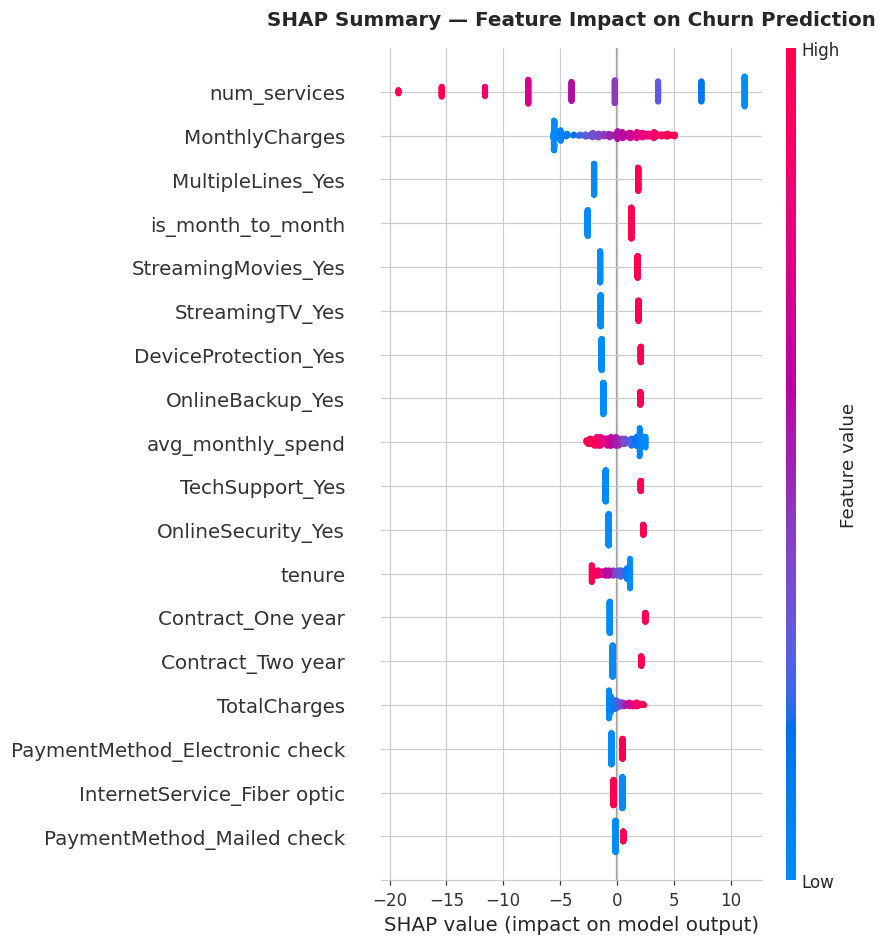

How to read this chart:
  - Features at the top have the most impact
  - RED dots = high feature value,  BLUE = low feature value
  - Dots on the RIGHT push towards churn, LEFT push towards staying


In [ ]:
# Summary plot — overall which features push churn up or down
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, show=False, max_display=18)
plt.title('SHAP Summary — Feature Impact on Churn Prediction',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("How to read this chart:")
print("  - Features at the top have the most impact")
print("  - RED dots = high feature value,  BLUE = low feature value")
print("  - Dots on the RIGHT push towards churn, LEFT push towards staying")

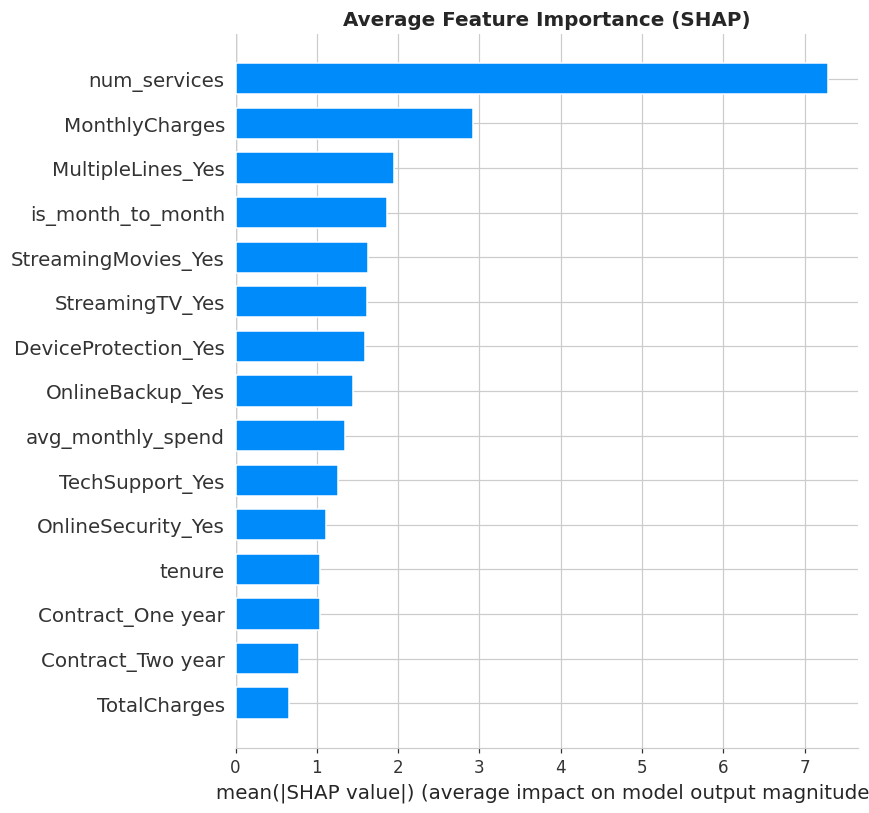

In [ ]:
# Bar summary — average absolute SHAP value per feature
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  max_display=15, show=False)
plt.title('Average Feature Importance (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Waterfall plot — explain a single customer's prediction
customer_idx = 5   # change this to look at a different customer
customer_data = X_sample.iloc[[customer_idx]]

if best_name != 'Logistic Regression':
    shap_explanation = explainer(customer_data)
    if isinstance(shap_explanation.values, np.ndarray) and shap_explanation.values.ndim == 3:
        # multi-class: pick class 1
        sv = shap_explanation.values[:, :, 1]
        bv = shap_explanation.base_values[:, 1]
        exp = shap.Explanation(values=sv[0], base_values=bv[0],
                               data=customer_data.values[0],
                               feature_names=customer_data.columns.tolist())
    else:
        exp = shap_explanation[0]

    print(f"Explaining prediction for Customer #{customer_idx}")
    prob = best_model_obj.predict_proba(customer_data)[0][1]
    print(f"Predicted churn probability: {prob*100:.1f}%")
    shap.plots.waterfall(exp, show=False, max_display=15)
    plt.title(f'Why did the model predict this customer? (Churn prob: {prob*100:.1f}%)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Waterfall plots work best with tree-based models.")

Waterfall plots work best with tree-based models.


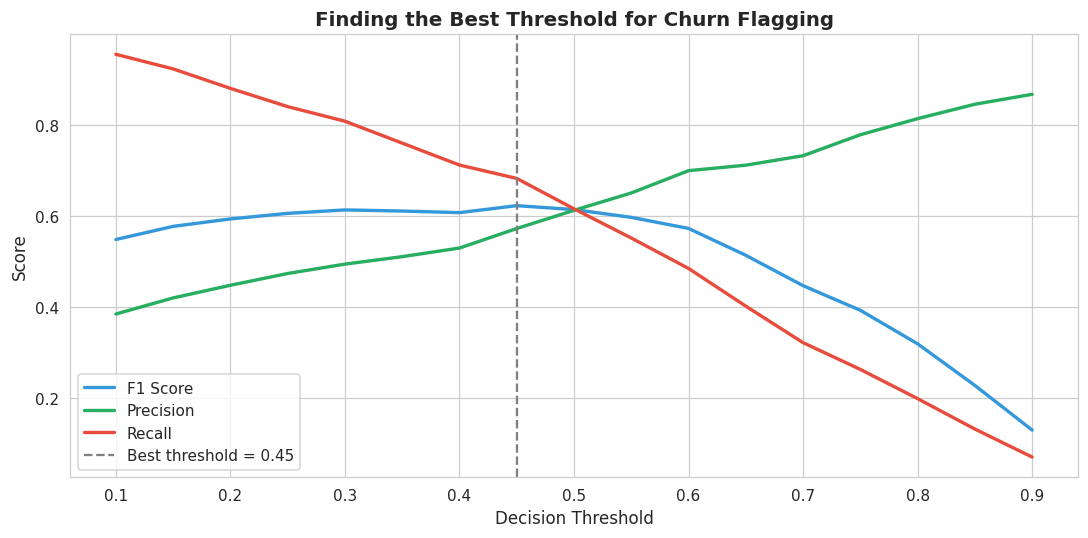

Best threshold (max F1): 0.45
At this threshold — F1: 0.622


In [ ]:
thresholds  = np.arange(0.10, 0.91, 0.05)
f1_list, prec_list, rec_list = [], [], []

for t in thresholds:
    p = (best['proba'] >= t).astype(int)
    f1_list.append(f1_score(y_test, p, zero_division=0))
    prec_list.append(precision_score(y_test, p, zero_division=0))
    rec_list.append(recall_score(y_test, p, zero_division=0))

best_t = thresholds[np.argmax(f1_list)]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_list,   label='F1 Score',  color='#3498db', lw=2.2)
plt.plot(thresholds, prec_list, label='Precision',  color='#27ae60', lw=2.2)
plt.plot(thresholds, rec_list,  label='Recall',     color='#e74c3c', lw=2.2)
plt.axvline(best_t, linestyle='--', color='gray', lw=1.5,
            label=f'Best threshold = {best_t:.2f}')
plt.xlabel('Decision Threshold', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Finding the Best Threshold for Churn Flagging',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Best threshold (max F1): {best_t:.2f}")
print(f"At this threshold — F1: {max(f1_list):.3f}")

In [ ]:
print(f"Running 5-fold cross-validation on {best_name}...")

cv_input = X_train_sc if best_name == 'Logistic Regression' else X_train_bal

cv_scores = cross_val_score(
    best_model_obj, cv_input, y_train_bal,
    cv=5, scoring='roc_auc', n_jobs=-1
)

print(f"CV ROC-AUC scores: {cv_scores.round(4)}")
print(f"Mean  : {cv_scores.mean():.4f}")
print(f"Std   : {cv_scores.std():.4f}")
print(f"\nA low standard deviation means the model is stable and consistent.")

Running 5-fold cross-validation on Logistic Regression...
CV ROC-AUC scores: [0.8323 0.8605 0.9811 0.9773 0.9756]
Mean  : 0.9254
Std   : 0.0651

A low standard deviation means the model is stable and consistent.


In [ ]:
joblib.dump(best_model_obj,       'churn_model.pkl')
joblib.dump(scaler,               'churn_scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'churn_features.pkl')

print("Saved files:")
print("  churn_model.pkl    — trained model")
print("  churn_scaler.pkl   — feature scaler")
print("  churn_features.pkl — list of expected feature names")

Saved files:
  churn_model.pkl    — trained model
  churn_scaler.pkl   — feature scaler
  churn_features.pkl — list of expected feature names


In [ ]:
feature_columns = X_train.columns.tolist()

def predict_churn(customer_dict, threshold=None):
    """
    Predicts whether a customer will churn.

    Parameters:
        customer_dict : dict — feature values for one customer
        threshold     : float — decision cutoff (default: best_t found earlier)

    Returns:
        'CHURN' or 'STAY'
    """
    if threshold is None:
        threshold = best_t

    row = pd.DataFrame([customer_dict])
    for col in feature_columns:
        if col not in row.columns:
            row[col] = 0
    row = row[feature_columns]

    if best_name == 'Logistic Regression':
        prob = best_model_obj.predict_proba(scaler.transform(row))[0][1]
    else:
        prob = best_model_obj.predict_proba(row)[0][1]

    verdict = 'CHURN RISK' if prob >= threshold else 'LIKELY TO STAY'

    print(f"  Churn probability : {prob*100:.1f}%")
    print(f"  Threshold used    : {threshold:.2f}")
    print(f"  Verdict           : {verdict}")
    return verdict, prob


# Test with a real churned customer
churned_customer = X_test[y_test == 1].iloc[0].to_dict()
stayed_customer  = X_test[y_test == 0].iloc[0].to_dict()

print("Test 1 — Customer who actually churned:")
predict_churn(churned_customer)

print("\nTest 2 — Customer who actually stayed:")
predict_churn(stayed_customer)

Test 1 — Customer who actually churned:
  Churn probability : 31.3%
  Threshold used    : 0.45
  Verdict           : LIKELY TO STAY

Test 2 — Customer who actually stayed:
  Churn probability : 5.2%
  Threshold used    : 0.45
  Verdict           : LIKELY TO STAY


('LIKELY TO STAY', np.float64(0.052495709675558534))

Customer Churn Risk Segmentation:
    risk_band  total_customers  actual_churners  avg_churn_prob  actual_churn_rate
    High Risk              126               98        0.848258               77.8
  Medium Risk              250              132        0.613296               52.8
     Low Risk              288               84        0.379709               29.2
Very Low Risk              745               60        0.083744                8.1


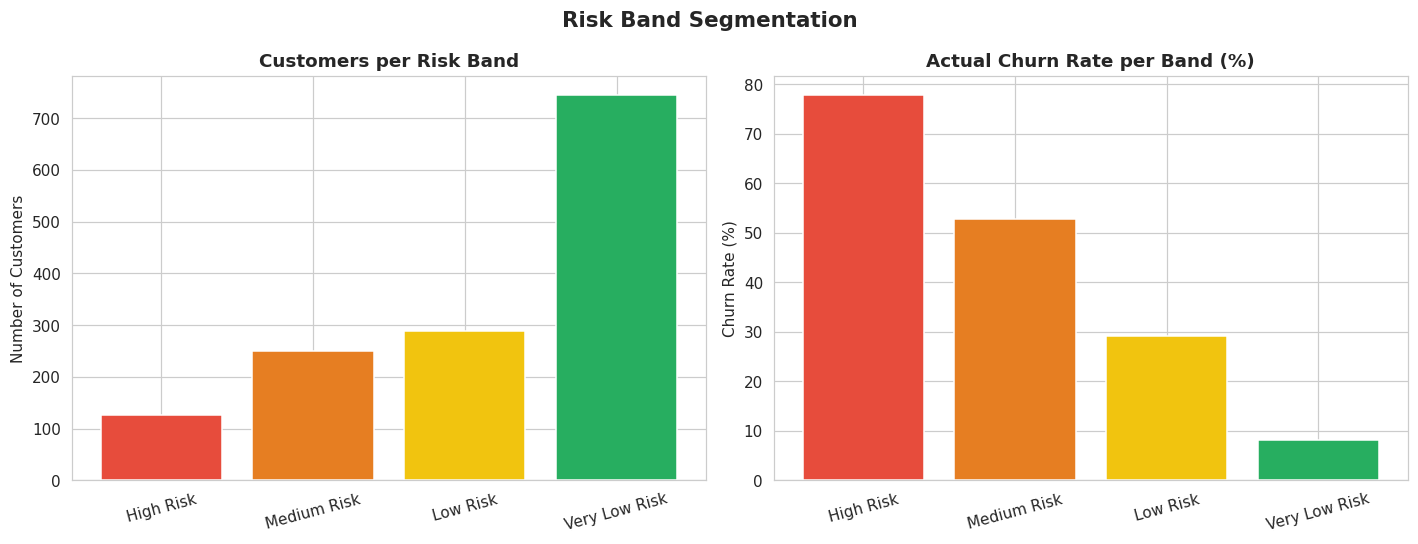

In [ ]:
# Churn Risk Segmentation — divide all test customers into risk bands
test_copy = X_test.copy()
test_copy['actual_churn']    = y_test.values
test_copy['churn_probability'] = best['proba']

def risk_band(p):
    if p >= 0.75:  return 'High Risk'
    elif p >= 0.50: return 'Medium Risk'
    elif p >= 0.25: return 'Low Risk'
    else:           return 'Very Low Risk'

test_copy['risk_band'] = test_copy['churn_probability'].apply(risk_band)

risk_summary = test_copy.groupby('risk_band').agg(
    total_customers = ('actual_churn', 'count'),
    actual_churners = ('actual_churn', 'sum'),
    avg_churn_prob  = ('churn_probability', 'mean')
).reset_index()
risk_summary['actual_churn_rate'] = (risk_summary['actual_churners'] /
                                      risk_summary['total_customers'] * 100).round(1)

order = ['High Risk', 'Medium Risk', 'Low Risk', 'Very Low Risk']
risk_summary['risk_band'] = pd.Categorical(risk_summary['risk_band'], categories=order, ordered=True)
risk_summary = risk_summary.sort_values('risk_band')

print("Customer Churn Risk Segmentation:")
print(risk_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_band = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60']

axes[0].bar(risk_summary['risk_band'], risk_summary['total_customers'],
            color=colors_band, edgecolor='white')
axes[0].set_title('Customers per Risk Band', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

axes[1].bar(risk_summary['risk_band'], risk_summary['actual_churn_rate'],
            color=colors_band, edgecolor='white')
axes[1].set_title('Actual Churn Rate per Band (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Risk Band Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()